# Worlds Shape Behavior

This notebook makes the world-dependence of behavior explicit. The central claim is simple: a cognitive mechanism is not meaningful in isolation, but only relative to the structure of the world in which it operates.

Here we read that claim in a `system_aw`-first way. `System A+W` is the main object of analysis because its internal machinery is rich enough to reveal how world structure shapes drive expression, movement, coverage, and survival. `System A` enters as a smaller contrast, mainly to show that world-dependence does not disappear in simpler systems, but becomes even harder to compensate for.

The notebook uses the curated series at `workspaces/system_a_vs_system_aw/series/world-variations`. Rather than covering every variant equally, we focus on four worlds that expose distinct environmental pressures:

- `world-baseline-anchor`: the bounded clustered reference world
- `world-open-fast-regen`: abundant regeneration with low friction
- `world-sparse-scarcity`: harsh scarcity with higher obstacle pressure
- `world-toroidal-wrap`: the same clustered regime as the baseline, but with different topology

Core message:

> Cognitive mechanisms only become meaningful relative to the structure of the world they operate in.


In [28]:
from _bootstrap import setup_notebook

ROOT = setup_notebook()

from pathlib import Path

import json
import math

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from research.lib import lines_plot, load_json, load_series_summary, workspace_path
from research.lib.plotting import ensure_matplotlib

pd.set_option('display.max_columns', 32)
pd.set_option('display.max_colwidth', 120)
plt = ensure_matplotlib()


## Why This Notebook Exists

Earlier notebooks explained the internal side of `system_aw`: hunger, curiosity, arbitration, and the closed agent-environment loop. This notebook turns the perspective outward. The question is no longer only *what does the system compute?* but also *what kind of world makes those computations matter in one way rather than another?*

That shift matters for two reasons.

First, the same internal mechanism can look adaptive in one world and fragile in another. A curiosity-weighted movement policy behaves differently when novelty is cheap, when food is dense, when obstacles create bottlenecks, or when topology removes edges altogether.

Second, world structure changes what the system even *gets to see*. Local observations, revisit patterns, resource encounter rates, and action admissibility are all world-shaped. The world is therefore not a passive backdrop. It actively sculpts the effective decision landscape the system inhabits.

This is also why AXIS separates `system` from `world`: the architecture makes it possible to hold the internal mechanism fixed and vary the environmental structure around it. That turns world-dependence from a vague philosophical claim into something measurable.

In [29]:
SERIES_DIR = workspace_path('system_a_vs_system_aw') / 'series' / 'world-variations'
SUMMARY_PATH = SERIES_DIR / 'measurements' / 'series-summary.json'
CURATED_LABELS = [
    'world-baseline-anchor',
    'world-open-fast-regen',
    'world-sparse-scarcity',
    'world-toroidal-wrap',
]
DISPLAY_NAMES = {
    'world-baseline-anchor': 'Baseline anchor',
    'world-open-fast-regen': 'Open fast regen',
    'world-sparse-scarcity': 'Sparse scarcity',
    'world-toroidal-wrap': 'Toroidal wrap',
}

series_summary = load_series_summary(SUMMARY_PATH)
entries = [entry for entry in series_summary['experiments'] if entry['label'] in CURATED_LABELS]
entries_by_label = {entry['label']: entry for entry in entries}


def experiment_config(experiment_id: str) -> dict:
    return load_json(SERIES_DIR / 'results' / experiment_id / 'experiment_config.json')


def behavior_metrics(experiment_id: str) -> dict:
    return load_json(SERIES_DIR / 'results' / experiment_id / 'runs' / 'run-0000' / 'behavior_metrics.json')


def run_summary(experiment_id: str) -> dict:
    return load_json(SERIES_DIR / 'results' / experiment_id / 'runs' / 'run-0000' / 'run_summary.json')


def episode_trace(experiment_id: str, episode_index: int) -> dict:
    return load_json(
        SERIES_DIR / 'results' / experiment_id / 'runs' / 'run-0000' / 'episodes' / f'episode_{episode_index:04d}.json'
    )


world_rows = []
for entry in entries:
    candidate_id = entry['candidate_experiment_id']
    reference_id = entry['reference_experiment_id']
    world_cfg = experiment_config(candidate_id)['world']
    cand_metrics = behavior_metrics(candidate_id)
    ref_summary = run_summary(reference_id)
    comp = entry['comparison_summary']
    world_rows.append(
        {
            'label': entry['label'],
            'world': DISPLAY_NAMES[entry['label']],
            'candidate_experiment_id': candidate_id,
            'reference_experiment_id': reference_id,
            'topology': world_cfg['topology'],
            'regen_mode': world_cfg['regeneration_mode'],
            'regen_rate': world_cfg['resource_regen_rate'],
            'obstacle_density': world_cfg['obstacle_density'],
            'clusters': world_cfg.get('num_clusters'),
            'regen_eligible_ratio': world_cfg.get('regen_eligible_ratio'),
            'aw_mean_steps': entry['run_summary']['mean_steps'],
            'aw_death_rate': entry['run_summary']['death_rate'],
            'aw_final_vitality': entry['run_summary']['mean_final_vitality'],
            'aw_resource_gain_per_step': cand_metrics['standard_metrics']['resource_gain_per_step']['mean'],
            'aw_net_energy_efficiency': cand_metrics['standard_metrics']['net_energy_efficiency']['mean'],
            'aw_coverage_efficiency': cand_metrics['standard_metrics']['coverage_efficiency']['mean'],
            'aw_unique_cells': cand_metrics['standard_metrics']['unique_cells_visited']['mean'],
            'aw_curiosity_dominance_rate': cand_metrics['system_specific_metrics']['system_aw_arbitration']['curiosity_dominance_rate'],
            'aw_curiosity_led_move_rate': cand_metrics['system_specific_metrics']['system_aw_behavior']['curiosity_led_move_rate'],
            'a_mean_steps': ref_summary['mean_steps'],
            'a_death_rate': ref_summary['death_rate'],
            'a_final_vitality': ref_summary['mean_final_vitality'],
            'action_mismatch_rate': comp['action_mismatch_rate']['mean'],
            'mean_trajectory_distance': comp['mean_trajectory_distance']['mean'],
            'candidate_survival_rate': comp['candidate_survival_rate'],
            'reference_survival_rate': comp['reference_survival_rate'],
        }
    )

world_df = pd.DataFrame(world_rows).sort_values('label').reset_index(drop=True)
world_df


,label,world,candidate_experiment_id,reference_experiment_id,topology,regen_mode,regen_rate,obstacle_density,clusters,regen_eligible_ratio,aw_mean_steps,aw_death_rate,aw_final_vitality,aw_resource_gain_per_step,aw_net_energy_efficiency,aw_coverage_efficiency,aw_unique_cells,aw_curiosity_dominance_rate,aw_curiosity_led_move_rate,a_mean_steps,a_death_rate,a_final_vitality,action_mismatch_rate,mean_trajectory_distance,candidate_survival_rate,reference_survival_rate
0,world-baseline-anchor,Baseline anchor,e6c3d617e01f46b6bd4bceb522bf598f,f0bd896e9a8e4341af7d10b6cee888b8,bounded,clustered,0.010,0.20,3.0,0.10,183.54,0.22,0.567780,0.677468,0.702608,0.477271,80.28,0.183502,0.477934,171.82,0.38,0.462370,0.781004,10.297773,0.78,0.62
1,world-open-fast-regen,Open fast regen,09b8ca55f1f24ca4ab1f52a06b47e664,f7a863957a3348aa9e6f24ff1fa433b0,bounded,all_traversable,0.030,0.10,NaN,NaN,200.00,0.00,0.841700,0.890850,0.918402,0.294330,57.10,0.353900,0.826700,200.00,0.00,0.993180,0.856400,13.736700,1.00,1.00
2,world-sparse-scarcity,Sparse scarcity,b8f460c96f2f469d8cd9d6bf59e649ad,11c24efa89d94af48f6b710e91c0e4ba,bounded,sparse_fixed_ratio,0.008,0.22,NaN,0.06,175.24,0.46,0.206464,0.481465,0.496518,0.692113,118.34,0.101689,0.207030,129.60,0.96,0.006332,0.780222,10.762853,0.54,0.04
3,world-toroidal-wrap,Toroidal wrap,ee73ccc98893486a9a883cf05fd22a88,c3e2e09bf2ef417f9759011118f91722,toroidal,clustered,0.010,0.20,3.0,0.10,198.00,0.02,0.740480,0.824490,0.855820,0.425591,80.32,0.198485,0.530202,178.08,0.28,0.548000,0.789148,10.215303,0.98,0.72


## Curated World Overview

The table below is the compact experimental scaffold for the rest of the notebook.

Read it in two layers:

- The left half describes world structure: regeneration regime, topology, and obstacle pressure.
- The right half shows what the same `system_aw` mechanism looks like inside those worlds, plus a small `System A` contrast and a direct comparison summary.

A useful first intuition already appears here: worlds that are more forgiving do not merely improve survival. They also change what kind of behavior is worth expressing. A high-curiosity movement policy is much easier to sustain when exploration is not constantly punished by scarcity or dead ends.

In [30]:
overview_columns = [
    'world',
    'regen_mode',
    'topology',
    'regen_rate',
    'obstacle_density',
    'aw_mean_steps',
    'aw_death_rate',
    'aw_resource_gain_per_step',
    'aw_coverage_efficiency',
    'aw_curiosity_dominance_rate',
    'a_mean_steps',
    'a_death_rate',
    'mean_trajectory_distance',
]

overview_df = world_df[overview_columns].copy()
overview_df = overview_df.rename(
    columns={
        'regen_mode': 'regen mode',
        'topology': 'topology',
        'regen_rate': 'regen rate',
        'obstacle_density': 'obstacle density',
        'aw_mean_steps': 'AW mean steps',
        'aw_death_rate': 'AW death rate',
        'aw_resource_gain_per_step': 'AW gain / step',
        'aw_coverage_efficiency': 'AW coverage eff.',
        'aw_curiosity_dominance_rate': 'AW curiosity dom.',
        'a_mean_steps': 'A mean steps',
        'a_death_rate': 'A death rate',
        'mean_trajectory_distance': 'A vs AW traj dist',
    }
)

display(overview_df.round(3))


,world,regen mode,topology,regen rate,obstacle density,AW mean steps,AW death rate,AW gain / step,AW coverage eff.,AW curiosity dom.,A mean steps,A death rate,A vs AW traj dist
0,Baseline anchor,clustered,bounded,0.010,0.20,183.54,0.22,0.677,0.477,0.184,171.82,0.38,10.298
1,Open fast regen,all_traversable,bounded,0.030,0.10,200.00,0.00,0.891,0.294,0.354,200.00,0.00,13.737
2,Sparse scarcity,sparse_fixed_ratio,bounded,0.008,0.22,175.24,0.46,0.481,0.692,0.102,129.60,0.96,10.763
3,Toroidal wrap,clustered,toroidal,0.010,0.20,198.00,0.02,0.824,0.426,0.198,178.08,0.28,10.215


## Visualizing The Worlds

Metrics are easier to interpret once the underlying world geometries are visible. The next figure shows a **post-first-regen** snapshot for each curated environment.

That timing detail matters. In these worlds, the stored `initial_world` is structurally correct for topology and obstacles, but resources have not yet been regenerated. If we plotted the literal initial state, resource mass would be invisible. So for this section we reconstruct the world immediately after the first regeneration update, before meaningful behavior has unfolded.

Reading guide:

- white cells: traversable empty space
- dark cells: obstacles
- green intensity: resource mass immediately after the first regeneration tick
- red marker: agent start position

This is still only an early structural snapshot, not a full dynamic summary. But even this view is enough to see why the worlds impose different search problems. `Open fast regen` offers low-friction movement and broad resource eligibility. `Sparse scarcity` combines thinner regeneration with more obstacles, turning search itself into a metabolic burden. `Toroidal wrap` keeps clustered regeneration but removes edge boundaries, which changes how trajectories fold back into the world.

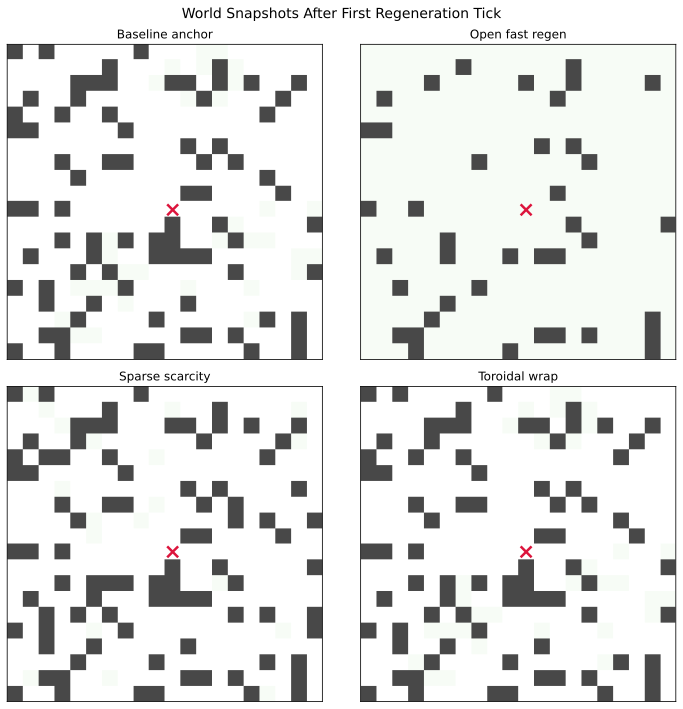

In [31]:
def post_first_regen_snapshot(experiment_id: str) -> dict:
    episode = episode_trace(experiment_id, 1)
    world = json.loads(json.dumps(episode['initial_world']))
    first_step = episode['steps'][0]
    for changed in first_step['regen_delta']['changed_cells']:
        x = changed['position']['x']
        y = changed['position']['y']
        world['grid'][y][x] = changed['cell']
    return world


def world_arrays(world_snapshot: dict) -> tuple[np.ndarray, np.ndarray, tuple[int, int]]:
    grid = world_snapshot['grid']
    height = len(grid)
    width = len(grid[0])
    resources = np.zeros((height, width), dtype=float)
    obstacles = np.zeros((height, width), dtype=float)
    for y, row in enumerate(grid):
        for x, cell in enumerate(row):
            resources[y, x] = cell['resource_value']
            obstacles[y, x] = 1.0 if cell['cell_type'] == 'obstacle' else 0.0
    agent = world_snapshot['agent_position']
    return resources, obstacles, (agent['x'], agent['y'])


fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, label in zip(axes, CURATED_LABELS):
    entry = entries_by_label[label]
    world_snapshot = post_first_regen_snapshot(entry['candidate_experiment_id'])
    resources, obstacles, agent_xy = world_arrays(world_snapshot)
    resource_mask = np.ma.masked_where(resources <= 0.0, resources)

    ax.imshow(np.zeros_like(resources), cmap='Greys', vmin=0.0, vmax=1.0)
    ax.imshow(obstacles, cmap='Greys', vmin=0.0, vmax=1.0, alpha=0.85)
    ax.imshow(resource_mask, cmap='Greens', alpha=0.95)
    ax.scatter(agent_xy[0], agent_xy[1], s=120, marker='x', color='crimson', linewidths=2.5)
    ax.set_title(DISPLAY_NAMES[label])
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('World Snapshots After First Regeneration Tick', fontsize=14)
fig.tight_layout()

## Metric View: The Same System Across Different Worlds

We can now ask the main empirical question of the notebook: what happens when the internal mechanism is held fixed and only the world changes?

The figure below focuses on four `system_aw` outcomes that together tell a useful story:

- `survival rate`: whether the overall world is metabolically livable
- `resource gain per step`: how effectively the world returns value per unit time
- `coverage efficiency`: how much of the world can be explored without wasteful revisiting
- `curiosity-led move rate`: how often movement is strongly shaped by curiosity pressure rather than hunger pressure

A key pattern to watch for is that these metrics do not move together in a trivial way. A world can improve survival while reducing coverage, because the agent no longer needs to range widely. Conversely, a harsh world can increase coverage because the agent is forced to search harder, even while overall viability drops.

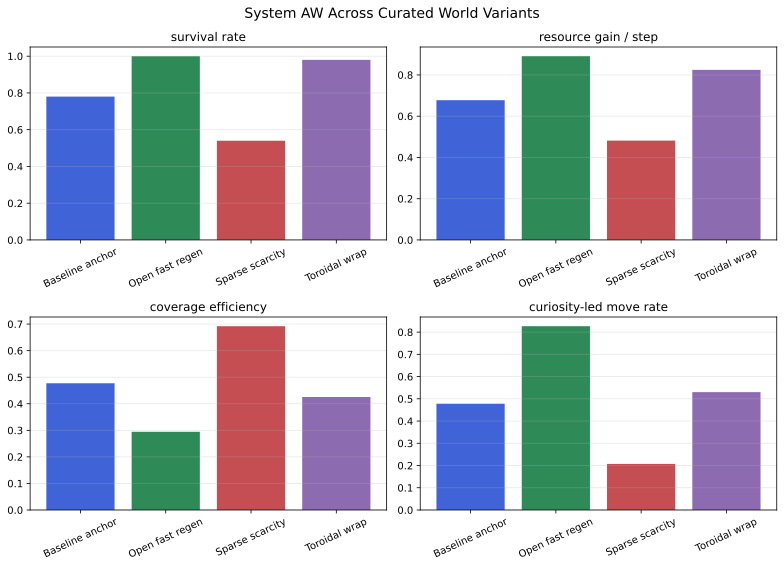

In [32]:
metric_cols = [
    ('candidate_survival_rate', 'survival rate'),
    ('aw_resource_gain_per_step', 'resource gain / step'),
    ('aw_coverage_efficiency', 'coverage efficiency'),
    ('aw_curiosity_led_move_rate', 'curiosity-led move rate'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
labels = world_df['world'].tolist()

for ax, (col, title) in zip(axes, metric_cols):
    ax.bar(labels, world_df[col], color=['#4063D8', '#2E8B57', '#C44E52', '#8C6BB1'])
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=25)

fig.suptitle('System AW Across Curated World Variants', fontsize=14)
fig.tight_layout()


Two contrasts are especially instructive.

`Open fast regen` is the easiest world in the set. Survival saturates, resource gain is high, and curiosity-led movement is also high. The system can afford exploration because the world does not punish it strongly.

`Sparse scarcity` produces the opposite regime. Coverage goes up because the agent must search more widely, but resource gain per step drops and survival collapses. This is exactly the kind of pattern that shows why raw exploration is not itself a success condition. The meaning of exploration depends on what the world yields in return.

## Small Contrast: `System A` vs `System A+W`

The next figure adds a smaller cross-system comparison. This is not the main point of the notebook, but it sharpens the world-dependence claim.

`System A` and `System A+W` do not merely differ by internal richness. They also differ in how much world structure they can exploit. When the world becomes harsh, the curiosity and world-model components in `system_aw` can sometimes convert environmental structure into usable search guidance. When the world is already extremely forgiving, the advantage narrows because almost any locally sensible policy can survive.

So the cross-system comparison should not be read as “better mind beats worse mind” in the abstract. It should be read as “different mechanisms extract different value from different worlds.”

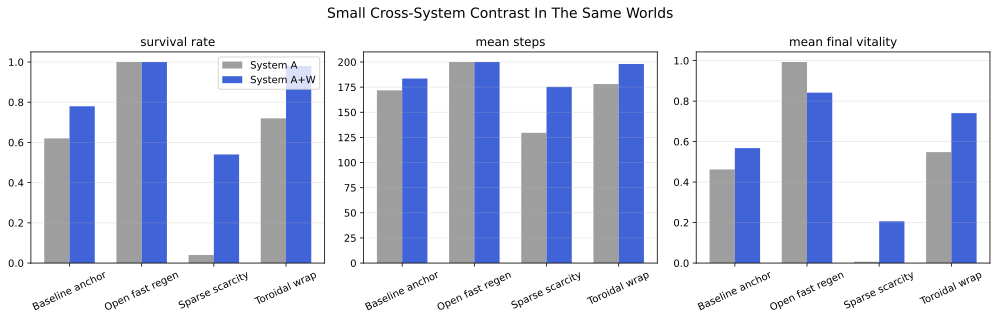

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
x = np.arange(len(world_df))
width = 0.35

comparisons = [
    ('candidate_survival_rate', 'reference_survival_rate', 'survival rate'),
    ('aw_mean_steps', 'a_mean_steps', 'mean steps'),
    ('aw_final_vitality', 'a_final_vitality', 'mean final vitality'),
]

for ax, (aw_col, a_col, title) in zip(axes, comparisons):
    ax.bar(x - width / 2, world_df[a_col], width=width, label='System A', color='#9E9E9E')
    ax.bar(x + width / 2, world_df[aw_col], width=width, label='System A+W', color='#4063D8')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(world_df['world'], rotation=25)
    ax.grid(True, axis='y', alpha=0.3)

axes[0].legend()
fig.suptitle('Small Cross-System Contrast In The Same Worlds', fontsize=14)
fig.tight_layout()


Three observations matter here.

- In `open fast regen`, both systems survive perfectly. Abundance compresses the functional difference.
- In `sparse scarcity`, the difference becomes dramatic. The world is not merely worse overall; it is selectively worse for a system with less exploratory structure.
- In `toroidal wrap`, `system_aw` gains from the topological change more strongly than `System A`, suggesting that its exploratory machinery can benefit from the removal of boundary traps and edge-induced revisiting.

This is the notebook's main conceptual pivot: a mechanism is not just evaluated by what it computes internally, but by the kinds of worlds in which those computations can convert into robust behavior.

## Divergence Is Also A World Effect

The comparison summaries include two especially useful quantities:

- `action mismatch rate`: how often `System A` and `System A+W` choose different actions in paired episodes
- `mean trajectory distance`: how far apart their realized trajectories become

These are not performance metrics in the narrow sense. They are *behavioral divergence* metrics. They tell us how strongly world structure amplifies internal mechanistic differences into different lived paths through the environment.

This is worth emphasizing because it helps avoid a common mistake: if two systems both survive, it does not follow that they behaved in the same way. A generous world can hide major mechanistic differences behind convergent survival outcomes.

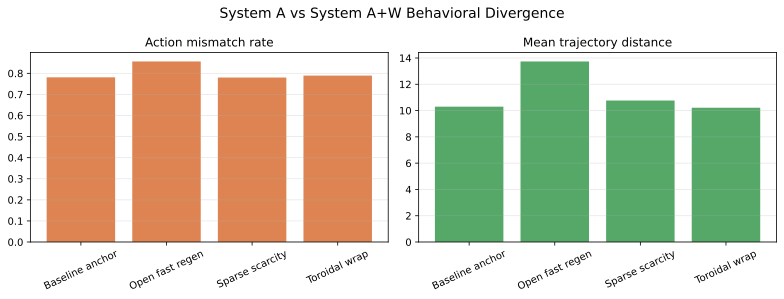

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(world_df['world'], world_df['action_mismatch_rate'], color='#DD8452')
axes[0].set_title('Action mismatch rate')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(world_df['world'], world_df['mean_trajectory_distance'], color='#55A868')
axes[1].set_title('Mean trajectory distance')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=25)

fig.suptitle('System A vs System A+W Behavioral Divergence', fontsize=14)
fig.tight_layout()


The striking case is `open fast regen`. Both systems survive perfectly, yet both action mismatch and trajectory distance are high. In other words, abundance can erase outcome differences without erasing mechanistic differences.

By contrast, `sparse scarcity` combines high divergence with a large survival gap. There the world does not merely reveal different policies. It differentially rewards them. This is a more severe form of world dependence: environmental structure becomes selective pressure.

## Trace Contrast 1: Topology Changes Search Geometry

The next figure overlays representative `system_aw` trajectories on the baseline and toroidal worlds. The internal mechanism is held fixed. The main structural change is topology.

We use representative episodes rather than cherry-picked extremes. The goal is not to find the most dramatic possible run, but to show a typical way in which the same mechanism gets routed differently by different world geometry.

Reading guide:

- the **thin blue line** is the traversed path between adjacent positions
- the **small colored points** are the visited positions themselves, colored by timestep from early to late
- the **red `x`** marks the start position
- the **gold circles** mark `consume` actions
- in the toroidal case, wrap transitions are drawn as **broken path segments** rather than misleading long straight lines across the plot

That last point matters. A toroidal move from one edge to the opposite edge is locally adjacent in the world, but discontinuous in plotted Cartesian coordinates. So the visualization intentionally breaks the line at those transitions.

Text(0.5, 0.98, 'Representative System AW Trajectories')

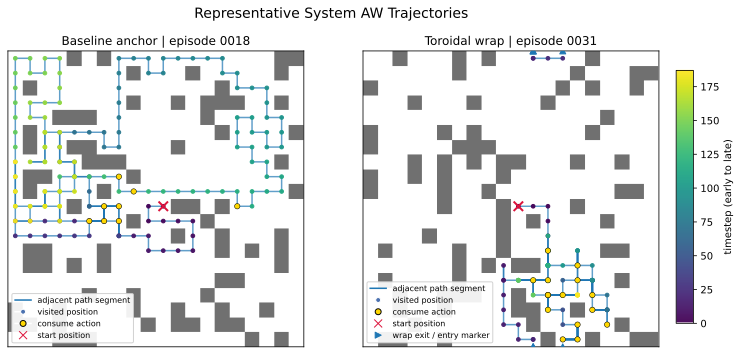

In [35]:
def load_all_episodes(experiment_id: str) -> list[tuple[int, dict]]:
    episodes_dir = SERIES_DIR / 'results' / experiment_id / 'runs' / 'run-0000' / 'episodes'
    pairs = []
    for path in sorted(episodes_dir.glob('episode_*.json')):
        episode_index = int(path.stem.split('_')[1])
        pairs.append((episode_index, load_json(path)))
    return pairs


def representative_episode(experiment_id: str) -> tuple[int, dict]:
    episodes = load_all_episodes(experiment_id)
    mean_steps = run_summary(experiment_id)['mean_steps']
    ranked = sorted(
        episodes,
        key=lambda pair: (
            abs(pair[1]['total_steps'] - mean_steps),
            0 if pair[1]['termination_reason'] == 'max_steps_reached' else 1,
            -pair[1]['final_vitality'],
        ),
    )
    return ranked[0]


def trajectory_xy(episode: dict) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    xs = [episode['initial_world']['agent_position']['x']]
    ys = [episode['initial_world']['agent_position']['y']]
    consumes = []
    for idx, step in enumerate(episode['steps']):
        xs.append(step['agent_position_after']['x'])
        ys.append(step['agent_position_after']['y'])
        if step['action'] == 'consume':
            consumes.append(idx + 1)
    return np.array(xs), np.array(ys), np.array(consumes, dtype=int)


def plot_trajectory(ax, episode: dict, *, topology: str, title: str):
    resources, obstacles, agent_xy = world_arrays(episode['initial_world'])
    resource_mask = np.ma.masked_where(resources <= 0.0, resources)
    ax.imshow(np.zeros_like(resources), cmap='Greys', vmin=0.0, vmax=1.0)
    ax.imshow(obstacles, cmap='Greys', vmin=0.0, vmax=1.0, alpha=0.75)
    ax.imshow(resource_mask, cmap='YlGn', alpha=0.8)

    xs, ys, consume_idx = trajectory_xy(episode)
    width = resources.shape[1]
    height = resources.shape[0]

    for i in range(len(xs) - 1):
        dx = abs(xs[i + 1] - xs[i])
        dy = abs(ys[i + 1] - ys[i])
        wraps = topology == 'toroidal' and (dx > 1 or dy > 1)
        if wraps:
            continue
        ax.plot(xs[i:i+2], ys[i:i+2], color='#1f77b4', linewidth=1.5, alpha=0.7)

    scatter = ax.scatter(xs, ys, c=np.arange(len(xs)), cmap='viridis', s=14, alpha=0.95, zorder=3)
    if len(consume_idx) > 0:
        ax.scatter(xs[consume_idx], ys[consume_idx], s=30, color='gold', edgecolors='black', linewidths=0.5, zorder=4)
    ax.scatter(xs[0], ys[0], s=90, marker='x', color='crimson', linewidths=2.0, zorder=5)

    if topology == 'toroidal':
        for i in range(len(xs) - 1):
            dx = xs[i + 1] - xs[i]
            dy = ys[i + 1] - ys[i]
            wraps = abs(dx) > 1 or abs(dy) > 1
            if not wraps:
                continue
            if abs(dx) > 1:
                exit_x = width - 0.5 if dx < 0 else -0.5
                entry_x = -0.5 if dx < 0 else width - 0.5
                exit_y = ys[i]
                entry_y = ys[i + 1]
                ax.scatter([exit_x, entry_x], [exit_y, entry_y], marker='>', s=36, color='#1f77b4', zorder=4)
            if abs(dy) > 1:
                exit_y = height - 0.5 if dy < 0 else -0.5
                entry_y = -0.5 if dy < 0 else height - 0.5
                exit_x = xs[i]
                entry_x = xs[i + 1]
                ax.scatter([exit_x, entry_x], [exit_y, entry_y], marker='^', s=36, color='#1f77b4', zorder=4)

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color='#1f77b4', lw=1.5, label='adjacent path segment'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=5, label='visited position'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gold', markeredgecolor='black', markersize=6, label='consume action'),
        Line2D([0], [0], marker='x', color='crimson', markersize=8, lw=0, label='start position'),
    ]
    if topology == 'toroidal':
        legend_handles.append(
            Line2D([0], [0], marker='>', color='#1f77b4', markersize=6, lw=0, label='wrap exit / entry marker')
        )
    ax.legend(handles=legend_handles, loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return scatter


baseline_idx, baseline_episode = representative_episode(entries_by_label['world-baseline-anchor']['candidate_experiment_id'])
toroid_idx, toroid_episode = representative_episode(entries_by_label['world-toroidal-wrap']['candidate_experiment_id'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
scatter = plot_trajectory(
    axes[0],
    baseline_episode,
    topology='bounded',
    title=f"{DISPLAY_NAMES['world-baseline-anchor']} | episode {baseline_idx:04d}",
)
plot_trajectory(
    axes[1],
    toroid_episode,
    topology='toroidal',
    title=f"{DISPLAY_NAMES['world-toroidal-wrap']} | episode {toroid_idx:04d}",
)

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.18, 0.02, 0.64])
cbar = fig.colorbar(scatter, cax=cax)
cbar.set_label('timestep (early to late)')
fig.suptitle('Representative System AW Trajectories', fontsize=14)

The topology effect is subtle but important.

The baseline world is bounded, so edge contact creates local dead-end structure and can increase revisiting pressure. In the toroidal world, the same clustered regeneration logic is embedded in a space without hard edges. That changes the geometry of search. A move that would previously terminate a local corridor instead folds back into another region of the world.

The point is not that toroidal topology is “better” in any universal sense. The point is that topology changes what counts as an efficient exploratory path. The same curiosity and hunger machinery is now operating over a different navigational manifold.

## Trace Contrast 2: Scarcity Changes The Metabolic Meaning Of Exploration

Now we contrast `open fast regen` with `sparse scarcity`. This comparison is especially useful because the worlds differ not only in obstacle structure but also in regeneration regime and effective environmental abundance.

The figure below plots vitality over time for representative `system_aw` episodes and marks `consume` actions. This gives us a compact trace-level view of the cost-return structure the world imposes on the agent.

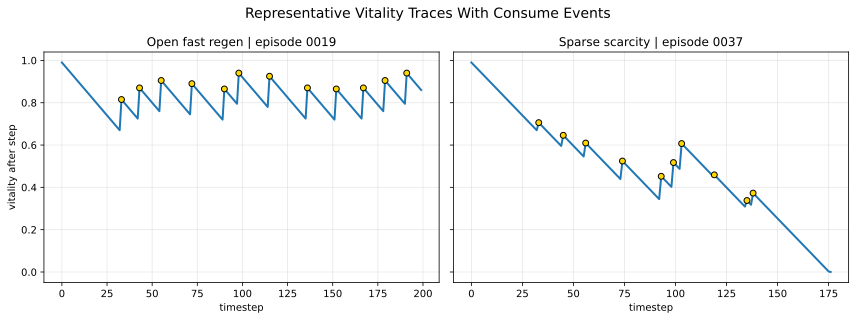

In [36]:
open_idx, open_episode = representative_episode(entries_by_label['world-open-fast-regen']['candidate_experiment_id'])
sparse_idx, sparse_episode = representative_episode(entries_by_label['world-sparse-scarcity']['candidate_experiment_id'])


def vitality_frame(episode: dict) -> pd.DataFrame:
    rows = []
    for step in episode['steps']:
        obs = step['system_data']['decision_data']['observation']
        rows.append(
            {
                'timestep': step['timestep'],
                'action': step['action'],
                'vitality_before': step['vitality_before'],
                'vitality_after': step['vitality_after'],
                'current_resource': obs['current']['resource'],
                'neighbor_resource_sum': sum(obs[direction]['resource'] for direction in ('up', 'down', 'left', 'right')),
            }
        )
    return pd.DataFrame(rows)


open_vitality_df = vitality_frame(open_episode)
sparse_vitality_df = vitality_frame(sparse_episode)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, df, title in [
    (axes[0], open_vitality_df, f'Open fast regen | episode {open_idx:04d}'),
    (axes[1], sparse_vitality_df, f'Sparse scarcity | episode {sparse_idx:04d}'),
]:
    ax.plot(df['timestep'], df['vitality_after'], linewidth=2.0)
    consume_df = df[df['action'] == 'consume']
    ax.scatter(consume_df['timestep'], consume_df['vitality_after'], color='gold', edgecolors='black', s=35, zorder=3)
    ax.set_title(title)
    ax.set_xlabel('timestep')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('vitality after step')
fig.suptitle('Representative Vitality Traces With Consume Events', fontsize=14)
fig.tight_layout()


In [37]:
def inter_consume_summary(episode: dict) -> dict:
    consume_steps = [step['timestep'] for step in episode['steps'] if step['action'] == 'consume']
    if len(consume_steps) < 2:
        return {'num_consumes': len(consume_steps), 'mean_gap': math.nan, 'max_gap': math.nan}
    gaps = np.diff(consume_steps)
    return {
        'num_consumes': len(consume_steps),
        'mean_gap': float(np.mean(gaps)),
        'max_gap': int(np.max(gaps)),
    }


trace_summary_df = pd.DataFrame(
    [
        {
            'world': 'Open fast regen',
            'episode': open_idx,
            'termination': open_episode['termination_reason'],
            'total_steps': open_episode['total_steps'],
            'final_vitality': open_episode['final_vitality'],
            **inter_consume_summary(open_episode),
        },
        {
            'world': 'Sparse scarcity',
            'episode': sparse_idx,
            'termination': sparse_episode['termination_reason'],
            'total_steps': sparse_episode['total_steps'],
            'final_vitality': sparse_episode['final_vitality'],
            **inter_consume_summary(sparse_episode),
        },
    ]
)

display(trace_summary_df.round(3))


,world,episode,termination,total_steps,final_vitality,num_consumes,mean_gap,max_gap
0,Open fast regen,19,max_steps_reached,200,0.86,12,14.364,21
1,Sparse scarcity,37,energy_depleted,177,0.00,10,11.667,19


This is where the world-dependence claim becomes mechanistically concrete.

In `open fast regen`, exploration is metabolically cheap. Resource encounters arrive often enough that vitality remains buffered, and curiosity can keep expressing itself without immediately becoming self-destructive.

In `sparse scarcity`, the exact same broad architecture faces a different cost-return landscape. Search paths are longer, local misses are more expensive, and consume opportunities are more weakly coupled to exploratory motion. Exploration is still present, but its functional meaning changes. It is no longer mostly opportunity-seeking. It becomes risk-bearing search under constraint.

In [38]:
def first_consume_window(episode: dict, radius: int = 3) -> pd.DataFrame:
    consume_indices = [i for i, step in enumerate(episode['steps']) if step['action'] == 'consume']
    if not consume_indices:
        return pd.DataFrame()
    center = consume_indices[0]
    lo = max(0, center - radius)
    hi = min(len(episode['steps']), center + radius + 1)
    rows = []
    for step in episode['steps'][lo:hi]:
        obs = step['system_data']['decision_data']['observation']
        rows.append(
            {
                'timestep': step['timestep'],
                'action': step['action'],
                'vitality_before': step['vitality_before'],
                'vitality_after': step['vitality_after'],
                'current_res': obs['current']['resource'],
                'up_res': obs['up']['resource'],
                'down_res': obs['down']['resource'],
                'left_res': obs['left']['resource'],
                'right_res': obs['right']['resource'],
            }
        )
    return pd.DataFrame(rows)


display(Markdown('### First Consume Window: Open Fast Regen'))
display(first_consume_window(open_episode).round(3))

display(Markdown('### First Consume Window: Sparse Scarcity'))
display(first_consume_window(sparse_episode).round(3))


### First Consume Window: Open Fast Regen

,timestep,action,vitality_before,vitality_after,current_res,up_res,down_res,left_res,right_res
0,30,right,0.700,0.690,0.90,0.90,0.90,0.90,0.90
1,31,up,0.690,0.680,0.93,0.93,0.00,0.93,0.00
2,32,right,0.680,0.670,0.96,0.96,0.96,0.96,0.96
3,33,consume,0.670,0.815,0.99,0.99,0.00,0.99,0.99
4,34,right,0.815,0.805,0.00,1.00,0.00,1.00,1.00
5,35,down,0.805,0.795,1.00,0.00,1.00,0.00,1.00
6,36,down,0.795,0.785,1.00,1.00,1.00,0.00,1.00


### First Consume Window: Sparse Scarcity

,timestep,action,vitality_before,vitality_after,current_res,up_res,down_res,left_res,right_res
0,30,up,0.700,0.690,0.000,0.24,0.0,0.000,0.0
1,31,right,0.690,0.680,0.248,0.00,0.0,0.000,0.0
2,32,left,0.680,0.670,0.000,0.00,0.0,0.256,0.0
3,33,consume,0.670,0.706,0.264,0.00,0.0,0.000,0.0
4,34,left,0.706,0.696,0.000,0.00,0.0,0.000,0.0
5,35,up,0.696,0.686,0.000,0.00,0.0,0.000,0.0
6,36,up,0.686,0.676,0.000,0.00,0.0,0.000,0.0


## What To Take Away

This notebook should leave us with five durable points.

- World dependence is not an optional interpretive layer. It is part of the mechanism's effective definition.
- Resource density, regeneration regime, obstacle structure, and topology all change the decision landscape presented to the same system.
- High exploration is not automatically good or bad. Its meaning depends on what the world yields in return.
- Cross-system comparisons are world-conditioned. A system's advantage appears, disappears, or changes shape depending on environmental structure.
- Episode traces are essential here. They let us move from aggregate claims like “scarcity hurts performance” to mechanistic ones like “scarcity lengthens search intervals between successful consumes and changes the metabolic meaning of movement.”

This is why AXIS treats worlds as first-class experimental objects. Cognitive mechanisms become legible only when we can vary the worlds that call those mechanisms into action.